# Rectangular Waveguide Modes

Rectangular metallic waveguides are one of the cleanest places where Maxwell theory becomes a genuine spectral problem: the conducting walls quantize the transverse field structure, cutoff frequencies appear automatically, and propagation along the guide is possible only above cutoff. This notebook develops the basic TE/TM mode formulas for a perfectly conducting guide, then studies a concrete WR-90 example numerically.

The goal is to keep the same workflow used elsewhere in this repository: theory first, computation second, and visualization third.


## Geometry, Separation, and Cutoff

Consider a perfectly conducting waveguide with cross section

$$
0 \le x \le a, \qquad 0 \le y \le b,
$$

with propagation along the $z$-direction and harmonic time dependence $e^{i \omega t - i \beta z}$. The longitudinal field component $\Psi$ satisfies the two-dimensional Helmholtz equation

$$
\left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} + k_c^2\right) \Psi = 0,
$$

where

$$
k_c^2 = k^2 - \beta^2, \qquad k = \frac{\omega}{c}.
$$

The boundary conditions at the conducting walls split the solutions into two families:

- **TM modes**: $E_z \ne 0$, $H_z = 0$, with

$$
E_z(x,y) = E_0 \sin\!\left(\frac{m \pi x}{a}\right) \sin\!\left(\frac{n \pi y}{b}\right), \qquad m,n = 1,2,3,\dots
$$

- **TE modes**: $H_z \ne 0$, $E_z = 0$, with

$$
H_z(x,y) = H_0 \cos\!\left(\frac{m \pi x}{a}\right) \cos\!\left(\frac{n \pi y}{b}\right), \qquad m,n \ge 0, \quad (m,n) \ne (0,0).
$$

Both families have the same cutoff wavenumber and cutoff frequency,

$$
k_c = \pi \sqrt{\left(\frac{m}{a}\right)^2 + \left(\frac{n}{b}\right)^2},
$$

$$
f_c = \frac{c}{2} \sqrt{\left(\frac{m}{a}\right)^2 + \left(\frac{n}{b}\right)^2}.
$$

The propagation constant is then

$$
\beta = k \sqrt{1 - \left(\frac{f_c}{f}\right)^2}.
$$

If $f < f_c$, then $\beta$ is imaginary and the mode is evanescent. If $f > f_c$, then $\beta$ is real and the mode propagates. In a rectangular guide with $a > b$, the dominant mode is usually $\mathrm{TE}_{10}$ because it has the lowest cutoff frequency.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

c = 299_792_458.0
mu0 = 4e-7 * np.pi
eps0 = 1.0 / (mu0 * c**2)

# Standard WR-90 dimensions, common in X-band microwave engineering.
a = 22.86e-3
b = 10.16e-3

print(f"Using WR-90 dimensions: a = {a * 1e3:.2f} mm, b = {b * 1e3:.2f} mm")


Using WR-90 dimensions: a = 22.86 mm, b = 10.16 mm


In [2]:
def cutoff_frequency(mode_type, m, n, a=a, b=b, c=c):
    if mode_type not in {"TE", "TM"}:
        raise ValueError("mode_type must be 'TE' or 'TM'.")

    if mode_type == "TE":
        if m < 0 or n < 0 or (m == 0 and n == 0):
            raise ValueError("TE modes require m,n >= 0 and not both zero.")
    else:
        if m < 1 or n < 1:
            raise ValueError("TM modes require m,n >= 1.")

    return 0.5 * c * np.sqrt((m / a) ** 2 + (n / b) ** 2)


def beta_from_frequency(f, fc, c=c):
    f = np.asarray(f, dtype=float)
    k0 = 2.0 * np.pi * f / c
    return k0 * np.sqrt(1.0 - (fc / f) ** 2 + 0j)


def rectangular_grid(nx=181, ny=101, a=a, b=b):
    x = np.linspace(0.0, a, nx)
    y = np.linspace(0.0, b, ny)
    X, Y = np.meshgrid(x, y, indexing="xy")
    return x, y, X, Y


def normalize_scalar(F):
    scale = np.max(np.abs(F))
    return F if scale == 0 else F / scale


def normalize_vector(U, V):
    scale = np.max(np.sqrt(U**2 + V**2))
    if scale == 0:
        return U, V
    return U / scale, V / scale


def te_mode_shapes(m, n, X, Y, a=a, b=b):
    if m == 0 and n == 0:
        raise ValueError("TE00 is not a physical mode.")

    kc2 = (m * np.pi / a) ** 2 + (n * np.pi / b) ** 2
    Hz = np.cos(m * np.pi * X / a) * np.cos(n * np.pi * Y / b)

    # These are normalized spatial mode shapes for the transverse electric field.
    Ex = (n * np.pi / b) * np.cos(m * np.pi * X / a) * np.sin(n * np.pi * Y / b) / kc2
    Ey = -(m * np.pi / a) * np.sin(m * np.pi * X / a) * np.cos(n * np.pi * Y / b) / kc2

    return normalize_scalar(Hz), *normalize_vector(Ex, Ey)


def tm_mode_shapes(m, n, X, Y, a=a, b=b):
    if m < 1 or n < 1:
        raise ValueError("TM modes require m,n >= 1.")

    kc2 = (m * np.pi / a) ** 2 + (n * np.pi / b) ** 2
    Ez = np.sin(m * np.pi * X / a) * np.sin(n * np.pi * Y / b)

    # For TM modes, the transverse electric field follows the gradient of E_z.
    Ex = (m * np.pi / a) * np.cos(m * np.pi * X / a) * np.sin(n * np.pi * Y / b) / kc2
    Ey = (n * np.pi / b) * np.sin(m * np.pi * X / a) * np.cos(n * np.pi * Y / b) / kc2

    return normalize_scalar(Ez), *normalize_vector(Ex, Ey)


def lowest_modes(mode_type, m_max, n_max):
    modes = []
    for m in range(m_max + 1):
        for n in range(n_max + 1):
            if mode_type == "TE":
                if m == 0 and n == 0:
                    continue
            else:
                if m == 0 or n == 0:
                    continue

            fc = cutoff_frequency(mode_type, m, n)
            modes.append((mode_type, m, n, fc))

    return sorted(modes, key=lambda item: item[3])


## Cutoff Spectrum for a Concrete Guide

A good way to build intuition is to sort the first few allowed modes by cutoff frequency. This immediately shows why the $\mathrm{TE}_{10}$ mode dominates practical rectangular waveguides: it is the first mode to turn from evanescent to propagating as frequency increases.


Lowest TE cutoffs:
  TE10:  6.557 GHz
  TE20: 13.114 GHz
  TE01: 14.754 GHz
  TE11: 16.145 GHz
  TE30: 19.671 GHz
  TE21: 19.740 GHz

Lowest TM cutoffs:
  TM11: 16.145 GHz
  TM21: 19.740 GHz
  TM31: 24.589 GHz
  TM41: 30.093 GHz
  TM12: 30.227 GHz
  TM22: 32.290 GHz


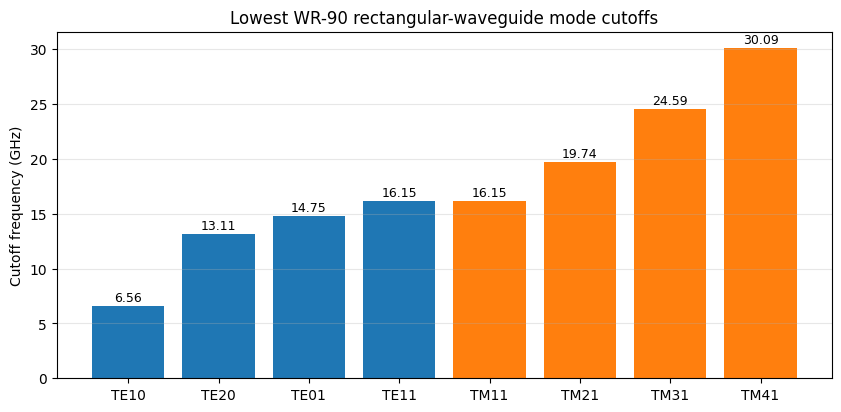

In [3]:
te_modes = lowest_modes("TE", m_max=4, n_max=3)[:6]
tm_modes = lowest_modes("TM", m_max=4, n_max=4)[:6]

print("Lowest TE cutoffs:")
for mode_type, m, n, fc in te_modes:
    print(f"  {mode_type}{m}{n}: {fc / 1e9:6.3f} GHz")

print("\nLowest TM cutoffs:")
for mode_type, m, n, fc in tm_modes:
    print(f"  {mode_type}{m}{n}: {fc / 1e9:6.3f} GHz")

combined = te_modes[:4] + tm_modes[:4]
labels = [f"{mode}{m}{n}" for mode, m, n, _ in combined]
values = [fc / 1e9 for _, _, _, fc in combined]
colors = ["tab:blue" if mode == "TE" else "tab:orange" for mode, _, _, _ in combined]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Cutoff frequency (GHz)")
ax.set_title("Lowest WR-90 rectangular-waveguide mode cutoffs")
ax.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, value + 0.15, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

plt.show()


## Mode Shapes in the Cross Section

The next figure shows representative mode shapes. The contour field is the normalized longitudinal phasor amplitude: $H_z$ for TE modes and $E_z$ for the TM mode. The arrows show the corresponding normalized transverse electric-field pattern. This is a phasor-shape view rather than an instantaneous real-time snapshot, so the figure emphasizes geometry more than time dependence.


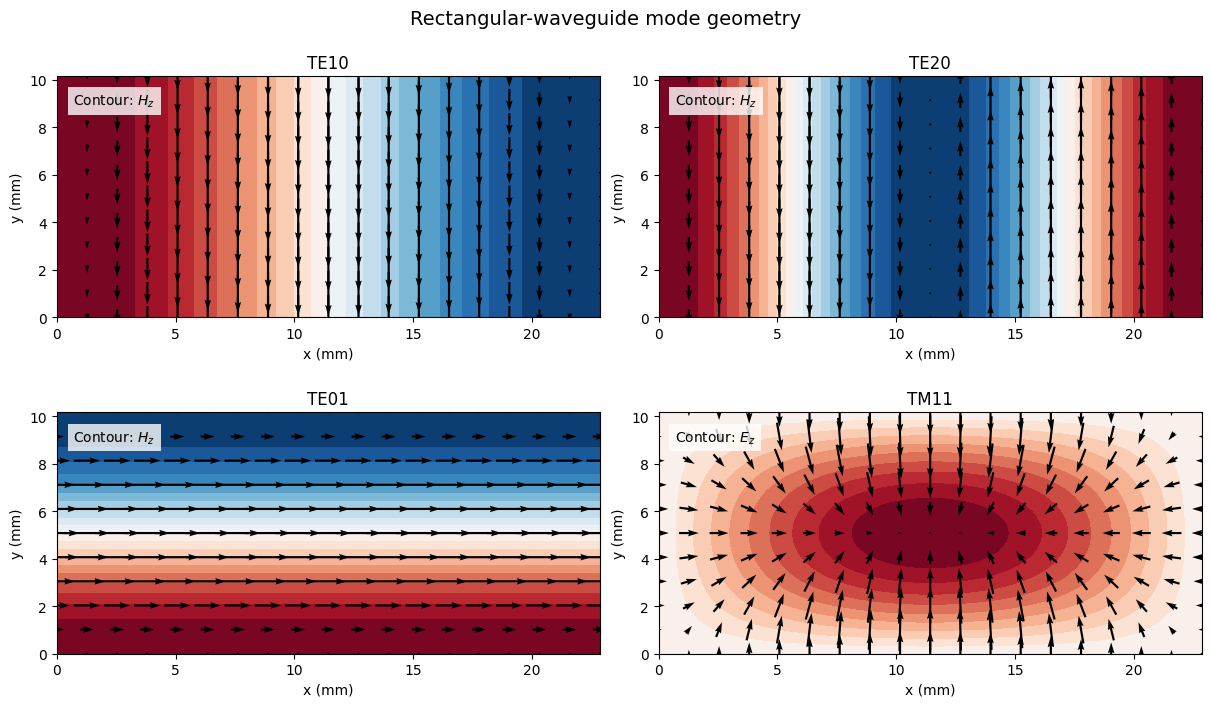

In [4]:
x, y, X, Y = rectangular_grid()
modes_to_plot = [("TE", 1, 0), ("TE", 2, 0), ("TE", 0, 1), ("TM", 1, 1)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for ax, (mode_type, m, n) in zip(axes.flat, modes_to_plot):
    if mode_type == "TE":
        scalar, U, V = te_mode_shapes(m, n, X, Y)
        scalar_name = "$H_z$"
    else:
        scalar, U, V = tm_mode_shapes(m, n, X, Y)
        scalar_name = "$E_z$"

    levels = np.linspace(-1.0, 1.0, 21)
    ax.contourf(X * 1e3, Y * 1e3, scalar, levels=levels, cmap="RdBu_r")

    step = 10
    ax.quiver(
        X[::step, ::step] * 1e3,
        Y[::step, ::step] * 1e3,
        U[::step, ::step],
        V[::step, ::step],
        color="black",
        pivot="mid",
        scale=12,
        width=0.004,
    )

    ax.set_title(f"{mode_type}{m}{n}")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_aspect("equal")
    ax.text(0.03, 0.93, f"Contour: {scalar_name}", transform=ax.transAxes, ha="left", va="top", fontsize=10, bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})

fig.suptitle("Rectangular-waveguide mode geometry", fontsize=14)
plt.show()


## Dispersion and Wave Speeds

Waveguides are dispersive even in vacuum because the boundaries impose a transverse eigenvalue problem. Above cutoff, each mode has a propagation constant $\beta(f)$ smaller than the free-space wavenumber $k_0 = 2 \pi f / c$. The phase velocity exceeds $c$, the group velocity stays below $c$, and their product satisfies $v_p v_g = c^2$ for an ideal hollow guide.


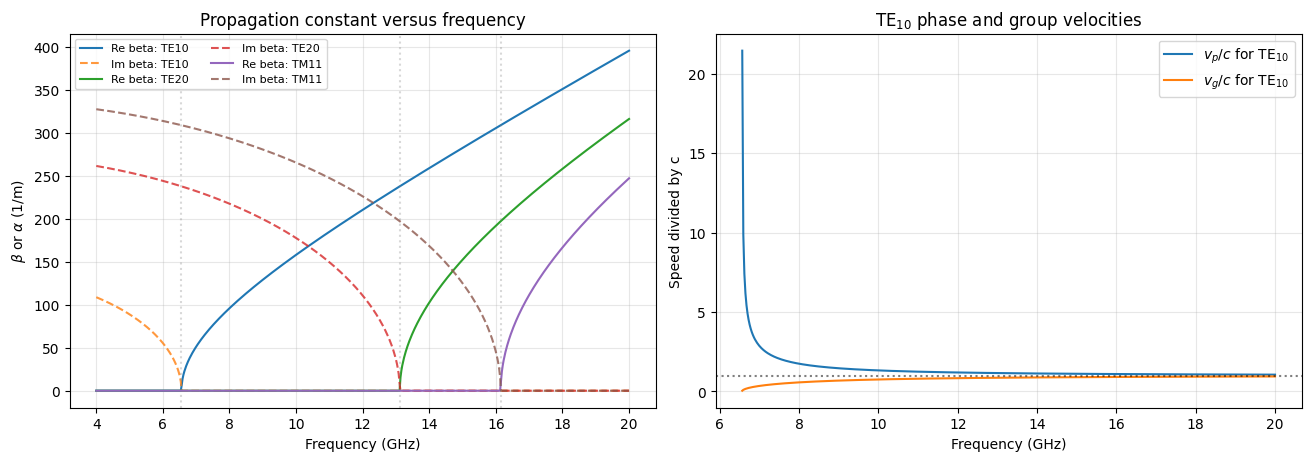

In [5]:
freqs = np.linspace(4.0e9, 20.0e9, 600)
mode_list = [("TE", 1, 0), ("TE", 2, 0), ("TM", 1, 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for mode_type, m, n in mode_list:
    fc = cutoff_frequency(mode_type, m, n)
    beta = beta_from_frequency(freqs, fc)
    label = f"{mode_type}{m}{n}"

    axes[0].plot(freqs / 1e9, np.real(beta), label=f"Re beta: {label}")
    axes[0].plot(freqs / 1e9, np.imag(beta), linestyle="--", alpha=0.8, label=f"Im beta: {label}")
    axes[0].axvline(fc / 1e9, color="gray", linestyle=":", alpha=0.3)

fc10 = cutoff_frequency("TE", 1, 0)
mask = freqs > 1.001 * fc10
vp = c / np.sqrt(1.0 - (fc10 / freqs[mask]) ** 2)
vg = c * np.sqrt(1.0 - (fc10 / freqs[mask]) ** 2)

axes[1].plot(freqs[mask] / 1e9, vp / c, label=r"$v_p/c$ for TE$_{10}$")
axes[1].plot(freqs[mask] / 1e9, vg / c, label=r"$v_g/c$ for TE$_{10}$")
axes[1].axhline(1.0, color="black", linestyle=":", alpha=0.5)

axes[0].set_title("Propagation constant versus frequency")
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel(r"$\beta$ or $\alpha$ (1/m)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

axes[1].set_title(r"TE$_{10}$ phase and group velocities")
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Speed divided by c")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


## A Traveling TE$_{10}$ Snapshot

Finally, it is useful to see what the dominant mode looks like as a function of both cross-guide position $x$ and distance along the guide $z$. The field below is a normalized real-part snapshot of the $E_y$ pattern for a $10\ \mathrm{GHz}$ TE$_{10}$ wave in WR-90, sampled at four times over one period. The transverse confinement is fixed by the sine profile in $x$, while the phase advances along $z$ with the guide wavelength.


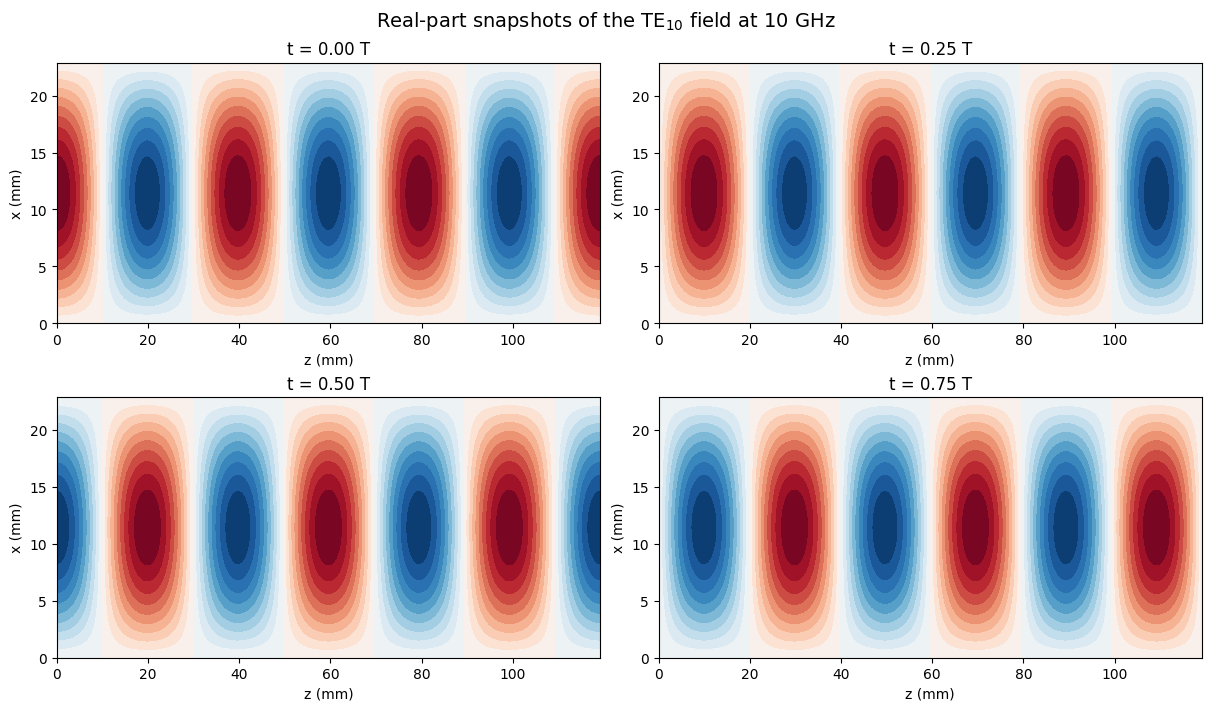

TE10 cutoff: 6.557 GHz
Guide wavelength at 10 GHz: 39.71 mm


In [6]:
frequency = 10.0e9
fc10 = cutoff_frequency("TE", 1, 0)
beta10 = float(np.real(beta_from_frequency(np.array([frequency]), fc10))[0])
guide_wavelength = 2.0 * np.pi / beta10
period = 1.0 / frequency

x_line = np.linspace(0.0, a, 220)
z_line = np.linspace(0.0, 3.0 * guide_wavelength, 320)
Xline, Zline = np.meshgrid(x_line, z_line, indexing="xy")

times = [0.0, 0.25 * period, 0.50 * period, 0.75 * period]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for ax, time in zip(axes.flat, times):
    Ey = np.sin(np.pi * Xline / a) * np.cos(2.0 * np.pi * frequency * time - beta10 * Zline)
    ax.contourf(z_line * 1e3, x_line * 1e3, Ey.T, levels=np.linspace(-1.0, 1.0, 21), cmap="RdBu_r")
    ax.set_title(f"t = {time / period:.2f} T")
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("x (mm)")

fig.suptitle(r"Real-part snapshots of the TE$_{10}$ field at 10 GHz", fontsize=14)
plt.show()

print(f"TE10 cutoff: {fc10 / 1e9:.3f} GHz")
print(f"Guide wavelength at 10 GHz: {guide_wavelength * 1e3:.2f} mm")


## Takeaways

- Perfectly conducting walls turn Maxwell's equations into a transverse eigenvalue problem.
- TE and TM modes share the same cutoff formula, but not the same allowed index sets.
- Below cutoff, the fields are evanescent; above cutoff, they propagate with a mode-dependent dispersion relation.
- The dominant rectangular-waveguide mode is usually $\mathrm{TE}_{10}$ because it has the smallest cutoff frequency.
- Even in vacuum, a waveguide is dispersive because geometry modifies the relation between frequency and propagation constant.

This notebook is a natural bridge from static boundary-value problems to guided-wave electromagnetics, cavity modes, and later FDTD or frequency-domain simulations.
